In [1]:
import numpy as np
from scipy.optimize import linprog
import pandas as pd
import pulp
import networkx as nx
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from joblib import Parallel, delayed

## 1. Récupération des données

### a. Chargement des données pour les années 2019 à 2023

In [2]:
# Chargement des données
df_solar_fr_2019 = pd.read_csv("./data_climix/2019/solar_2019.csv")
df_wind_fr_2019 = pd.read_csv("./data_climix/2019/wind_2019.csv")

df_solar_fr_2020 = pd.read_csv("./data_climix/2020/solar_2020.csv")
df_wind_fr_2020 = pd.read_csv("./data_climix/2020/wind_2020.csv")

df_solar_fr_2021 = pd.read_csv("./data_climix/2021/solar_2021.csv")
df_wind_fr_2021 = pd.read_csv("./data_climix/2021/wind_2021.csv")

df_solar_fr_2022 = pd.read_csv("./data_climix/2022/solar_2022.csv")
df_wind_fr_2022 = pd.read_csv("./data_climix/2022/wind_2022.csv")

df_solar_fr_2023 = pd.read_csv("./data_climix/2023/solar_2023.csv")
df_wind_fr_2023 = pd.read_csv("./data_climix/2023/wind_2023.csv")

df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]

# Calcul consommation annuelle
annual_demand = df_demand['demande'].sum()

# Calcul production potentielle pour 1GW installé
annual_solar_per_gw_fr_2019 = df_solar_fr_2019['facteur_charge'].sum()
annual_wind_per_gw_fr_2019 = df_wind_fr_2019['facteur_charge'].sum()

annual_solar_per_gw_fr_2020 = df_solar_fr_2020['facteur_charge'].sum()
annual_wind_per_gw_fr_2020 = df_wind_fr_2020['facteur_charge'].sum()

annual_solar_per_gw_fr_2021 = df_solar_fr_2021['facteur_charge'].sum()
annual_wind_per_gw_fr_2021 = df_wind_fr_2021['facteur_charge'].sum()

annual_solar_per_gw_fr_2022 = df_solar_fr_2022['facteur_charge'].sum()
annual_wind_per_gw_fr_2022 = df_wind_fr_2022['facteur_charge'].sum()

annual_solar_per_gw_fr_2023 = df_solar_fr_2023['facteur_charge'].sum()
annual_wind_per_gw_fr_2023 = df_wind_fr_2023['facteur_charge'].sum()

# Pour avoir 100% de surproduction et un mix 50-50
target_production = annual_demand * 3.5
wind_capacity_2019 = target_production/(2 * annual_wind_per_gw_fr_2019)
solar_capacity_2019 = target_production/(2 * annual_solar_per_gw_fr_2019)

wind_capacity_2020 = target_production/(2 * annual_wind_per_gw_fr_2020)
solar_capacity_2020 = target_production/(2 * annual_solar_per_gw_fr_2020)

wind_capacity_2021 = target_production/(2 * annual_wind_per_gw_fr_2021)
solar_capacity_2021 = target_production/(2 * annual_solar_per_gw_fr_2021)

wind_capacity_2022 = target_production/(2 * annual_wind_per_gw_fr_2022)
solar_capacity_2022 = target_production/(2 * annual_solar_per_gw_fr_2022)

wind_capacity_2023 = target_production/(2 * annual_wind_per_gw_fr_2023)
solar_capacity_2023 = target_production/(2 * annual_solar_per_gw_fr_2023)

In [19]:
# Configuration des années et types
pays = [2019, 2020, 2021, 2022, 2023]
N = len(pays)

solar_profiles = []
wind_profiles = []
wind_caps = []
solar_caps = []

df_demand = pd.read_csv('demand2050_ADEME.csv', header=None)
df_demand.columns = ["heures", "demande"]
demand_values = df_demand['demande'].values[:8760]*2.5

annual_demand = df_demand['demande'].sum()
target_production = annual_demand * 3.5

for p in pays:
    # --- Traitement SOLAIRE ---
    df_s = pd.read_csv(f"./data_climix/{p}/solar_{p}.csv")
    s_vals = df_s['facteur_charge'].values
    
    # Force la taille à 8760
    solar_fc = np.zeros(8760)
    length_s = min(len(s_vals), 8760)
    solar_fc[:length_s] = s_vals[:length_s]
    solar_profiles.append(solar_fc)
    
    # --- Traitement ÉOLIEN ---
    df_w = pd.read_csv(f"./data_climix/{p}/wind_{p}.csv")
    w_vals = df_w['facteur_charge'].values
    
    # Initialisation du cumul éolien à 8760
    wind_fc = np.zeros(8760)
    length_w = min(len(w_vals), 8760)
    wind_fc[:length_w] = w_vals[:length_w]
    wind_profiles.append(wind_fc)
    
    # Calcul des capacités
    ann_solar_gw = solar_fc.sum()
    ann_wind_gw = wind_fc.sum()
    
    wind_caps.append(target_production / (2 * ann_wind_gw))
    solar_caps.append(target_production / (2 * ann_solar_gw))

# Maintenant toutes les listes font exactement 8760, la conversion marchera :
solar_N = np.array(solar_profiles).T
wind_N = np.array(wind_profiles).T
demand_N = np.tile(demand_values, (N, 1)).T


wind_cap_N = np.array(wind_caps)
solar_cap_N = np.array(solar_caps)

print(f"\nDonnées prêtes : Matrice Solaire {solar_N.shape}, Matrice Éolienne {wind_N.shape}")


Données prêtes : Matrice Solaire (8760, 5), Matrice Éolienne (8760, 5)


### b. Chargement des valeurs d'échange maximales

In [20]:
T = len(df_demand)
N = 5

qmax11pays = np.array([[0 ,50,20,30,40,70,20,30,50,40,70],
                       [50,0 ,80,40,30,20,50,0 ,70,60,30],
                       [20,80,0 ,60,50,60,40,30,70,50,20],
                       [30,40,60,0 ,40,60,0 ,40,60,0 ,40],
                       [40,30,50,40,0 ,40,30,70,60,80,70],
                       [70,20,60,60,40,0 ,20,30,20,60,60],
                       [20,50,40,0 ,30,20,0 ,40,50,60,40],
                       [30,0 ,30,40,70,30,40,0 ,30,70,50],
                       [50,70,70,60,60,20,50,30,0 ,30,60],
                       [40,60,50,0 ,80,60,60,70,30,0 ,30],
                       [70,30,20,40,70,60,40,50,60,30,0 ]])

qmax = qmax11pays[:N,:N]

Ces données sont celles de la France sur 5 années différentes, il faudra prendre le temps de les changer pour avoir des résultats interressants.

--> voir ce site pour données réelles : https://transparency.entsoe.eu/

## 2. Définition du problème

## a. Code optimisation stockage 1 pays

In [ ]:
def optimize_storage(solar_profile, wind_profile, demand, wind_cap, solar_cap,
                    phs_capacity, phs_power, phs_eff,
                    ptg_capacity, ptg_power_in, ptg_power_out, 
                    ptg_eff, penalisation):
    """
    Optimise la stratégie de stockage sur l'année avec contrainte cyclique
    
    Parameters:
    -----------
    solar_profile, wind_profile: séries temporelles des facteurs de charge
    demand: série temporelle de la demande
    wind_cap, solar_cap: capacités installées en GW
    phs_capacity: capacité de stockage PHS en GWh
    phs_power: puissance max PHS en GW
    phs_eff: rendement PHS (aller-retour)
    ptg_capacity: capacité de stockage P2G en GWh
    ptg_power_in: puissance max électrolyse en GW  
    ptg_power_out: puissance max reconversion en GW
    ptg_eff: rendement P2G (aller-retour)
    """
    
    T = len(demand)  # nombre d'heures
    
    # Création du problème
    prob = pulp.LpProblem("Storage_Strategy", pulp.LpMinimize)
    
    # Variables
    phs_in = pulp.LpVariable.dicts("phs_in", range(T), 0)  # Charge PHS
    phs_out = pulp.LpVariable.dicts("phs_out", range(T), 0)  # Décharge PHS
    phs_level = pulp.LpVariable.dicts("phs_level", range(T), 0)  # Niveau PHS
    
    ptg_in = pulp.LpVariable.dicts("ptg_in", range(T), 0)  # Charge P2G
    ptg_out = pulp.LpVariable.dicts("ptg_out", range(T), 0)  # Décharge P2G
    ptg_level = pulp.LpVariable.dicts("ptg_level", range(T), 0)  # Niveau P2G
    
    deficit = pulp.LpVariable.dicts("deficit", range(T), 0)  # Déficit
    surplus = pulp.LpVariable.dicts("surplus", range(T), 0) # Surplus
    
    # Production ENR horaire
    prod = (
            wind_cap * wind_profile
            + solar_cap * solar_profile
        )
    
    # Fonction objectif : minimiser déficits
    prob += -ptg_level[T-1] + penalisation * pulp.lpSum(deficit[t] for t in range(T))
    
    # Contraintes
    
    # Niveaux initiaux
    prob += phs_level[0] == phs_capacity/2  # PHS à 50%
    prob += ptg_level[0] == ptg_capacity    # P2G plein
    
    # Contraintes cycliques : les niveaux finaux doivent être égaux aux niveaux initiaux
    #prob += phs_level[T-1] == phs_level[0]
    #prob += ptg_level[T-1] == ptg_level[0]
    
    for t in range(T):
        # Équilibre offre-demande
        prob += (
                prod[t] 
                + phs_out[t] * phs_eff 
                + ptg_out[t] * ptg_eff 
                + deficit[t]
                == 
                demand[t] 
                + phs_in[t] 
                + ptg_in[t]
                + surplus[t]
        )
        
        # Limites PHS
        prob += phs_in[t] <= phs_power
        prob += phs_out[t] <= phs_power
        prob += phs_level[t] <= phs_capacity
        
        # Limites P2G
        prob += ptg_in[t] <= ptg_power_in
        prob += ptg_out[t] <= ptg_power_out
        prob += ptg_level[t] <= ptg_capacity
        
        # Évolution des stocks
        if t > 0:
            prob += phs_level[t] == phs_level[t-1] + phs_in[t]*phs_eff - phs_out[t]
            prob += ptg_level[t] == ptg_level[t-1] + ptg_in[t]*ptg_eff - ptg_out[t]
       
        
    # Résolution
    prob.solve()
    
    return {
        'status': pulp.LpStatus[prob.status],
        'prod':prod,
        'phs_in': [phs_in[t].value() for t in range(T)],
        'phs_out': [phs_out[t].value() for t in range(T)],
        'phs_level': [phs_level[t].value() for t in range(T)],
        'ptg_in': [ptg_in[t].value() for t in range(T)],
        'ptg_out': [ptg_out[t].value() for t in range(T)],
        'ptg_level': [ptg_level[t].value() for t in range(T)],
        'deficit': [deficit[t].value() for t in range(T)],
        'surplus': [surplus[t].value() for t in range(T)]
    }


## b. Code optimisation des échanges n pays

In [22]:
def solve_flux(surplus, deficit, qmax_matrix, flux_eff, penalisation):
    """
    Résout le flux optimal pour N pays et T périodes, avec PuLP.

    surplus : np.array (T, N)
    deficit : np.array (T, N)
    qmax_matrix : np.array (N, N), symétrique, diag = 0
    """

    T, N = surplus.shape

    # Sécurité : contrôle taille qmax_matrix
    assert qmax_matrix.shape == (N, N), "qmax_matrix doit être de taille (N, N)"
    assert np.allclose(qmax_matrix, qmax_matrix.T), "qmax_matrix doit être symétrique"
    assert np.all(np.diag(qmax_matrix) == 0), "La diagonale de qmax_matrix doit être nulle"

    Q = surplus - deficit

    # Problème d'optimisation
    prob = pulp.LpProblem("Optimal_Flux", pulp.LpMinimize)

    # Flux inter-pays q[t,i,j]
    q = {}
    for t in range(T):
        for i in range(N):
            for j in range(N):
                if i != j:
                    q[t, i, j] = pulp.LpVariable(
                        f"q_{t}_{i}_{j}",
                        lowBound=0,
                        upBound=float(qmax_matrix[i, j])
                    )

    # Variables r_pos et r_neg
    r_pos, r_neg = {}, {}
    for t in range(T):
        for i in range(N):
            if Q[t, i] >= 0:
                r_pos[t, i] = pulp.LpVariable(f"r_pos_{t}_{i}", lowBound=0)
                r_neg[t, i] = pulp.LpVariable(f"r_neg_{t}_{i}", lowBound=0, upBound=0)
            else:
                r_pos[t, i] = pulp.LpVariable(f"r_pos_{t}_{i}", lowBound=0, upBound=0)
                r_neg[t, i] = pulp.LpVariable(f"r_neg_{t}_{i}", lowBound=0)

    # Fonction objectif : minimiser les déficites et maximiser les restes positifs
    prob += pulp.lpSum(penalisation*r_neg[t, i]-r_pos[t, i] for t in range(T) for i in range(N))

    # Contraintes de bilan
    for t in range(T):
        for i in range(N):
            inflow = pulp.lpSum(q[t, j, i] for j in range(N) if j != i)
            outflow = pulp.lpSum(q[t, i, j] for j in range(N) if j != i)
            prob += (
                r_pos[t, i] - r_neg[t, i]
                == surplus[t, i] - deficit[t, i] + flux_eff * inflow - outflow
            )

    # Résolution
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # Extraction solutions
    q_array = np.zeros((T, N, N))
    new_surplus = np.zeros((T, N))
    new_deficit= np.zeros((T, N))

    for t in range(T):
        for i in range(N):
            new_surplus[t, i] = pulp.value(r_pos[t, i])
            new_deficit[t, i] = pulp.value(r_neg[t, i])
            for j in range(N):
                if i != j:
                    q_array[t, i, j] = pulp.value(q[t, i, j])

    return {
        'echanges' : q_array,
        'surplus' : new_surplus,
        'deficit' : new_deficit
    }


## c. Combiner les deux optimisations

In [23]:
def optimize(
    wind_profile, solar_profile, demand,
    wind_cap, solar_cap, qmax_matrix,
    phs_capacity=180, phs_power=9.3, phs_eff=0.75,
    ptg_capacity=125000, ptg_power_in=7.66, ptg_power_out=32.93,
    ptg_eff=0.4, penalisation=1e10, flux_eff=0.9
):

    T, N = demand.shape

    # 1. Préparation de la fonction à appeler en parallèle
    # On définit une petite fonction interne ou on passe les arguments à optimize_storage
    def run_one_country(p):
        return optimize_storage(
            solar_profile[:, p], wind_profile[:, p], demand[:, p], 
            wind_cap[p], solar_cap[p], phs_capacity, phs_power, phs_eff, 
            ptg_capacity, ptg_power_in, ptg_power_out, ptg_eff, penalisation
        )

    # 2. Exécution en parallèle
    # n_jobs=-1 utilise tous les cœurs disponibles
    results = Parallel(n_jobs=-1)(delayed(run_one_country)(p) for p in range(N))

    # 3. Initialisation des matrices de stockage
    prod = np.zeros((T, N))
    phs_in, phs_out, phs_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    ptg_in, ptg_out, ptg_level = np.zeros((T, N)), np.zeros((T, N)), np.zeros((T, N))
    deficit_avant, surplus_avant = np.zeros((T, N)), np.zeros((T, N))

    # 4. Rassemblement des résultats
    for p, res in enumerate(results):
        prod[:, p] = res['prod']
        phs_in[:, p] = res['phs_in']
        phs_out[:, p] = res['phs_out']
        phs_level[:, p] = res['phs_level']
        ptg_in[:, p] = res['ptg_in']
        ptg_out[:, p] = res['ptg_out']
        ptg_level[:, p] = res['ptg_level']
        deficit_avant[:, p] = res['deficit']
        surplus_avant[:, p] = res['surplus']

    # 5. Optimisation des flux (reste séquentiel car global)
    result2 = solve_flux(surplus_avant, deficit_avant, qmax_matrix, flux_eff, penalisation)
    
    echanges=result2['echanges']
    deficit=result2['deficit']
    surplus=result2['surplus']


    return {
        
        'prod' : prod,
        
        'phs_in': phs_in,
        'phs_out': phs_out,
        'phs_level': phs_level,

        'ptg_in': ptg_in,
        'ptg_out': ptg_out,
        'ptg_level': ptg_level,
        
        'deficit avant echange' : deficit_avant,
        'surplus avant echange' : surplus_avant,

        'deficit': deficit,
        'surplus': surplus,

        'Echanges': echanges
    }
    
    

## 3. Execution de l'optimisation

In [24]:
result = optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=30*180, #modifié en faisant 30*
    phs_power=5*9.3,     #modifié en faisant 5*
    phs_eff=0.75,  
    ptg_capacity=125000,
    ptg_power_in=100*7.66,   #modifié en faisant 100*
    ptg_power_out=2*32.93,   #modifié en faisant 2*
    ptg_eff=0.4
)

## 4. Interprétation graphique

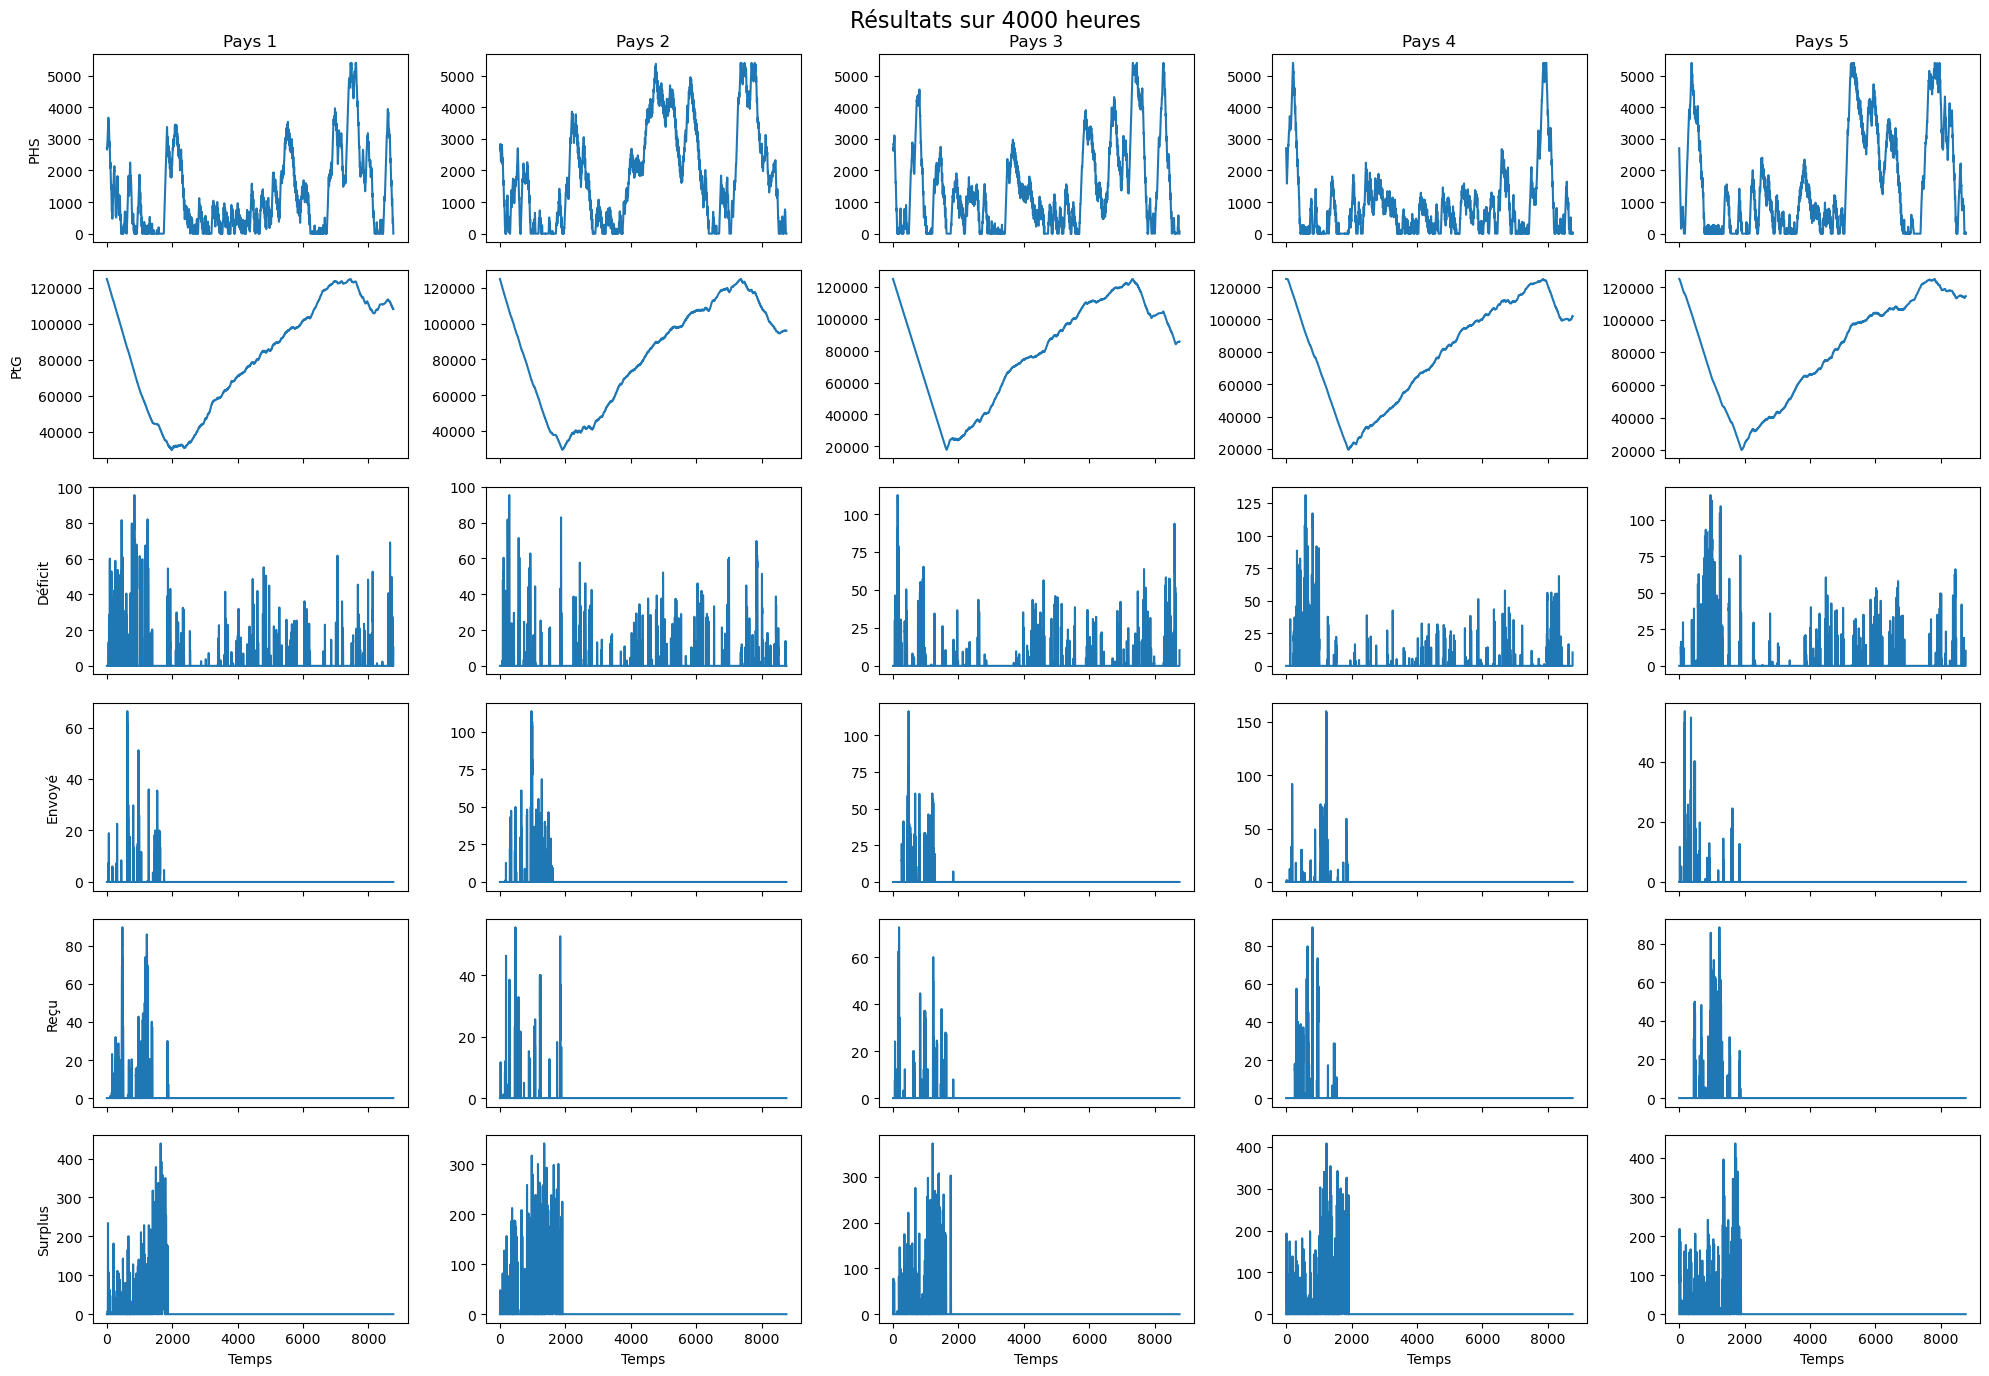

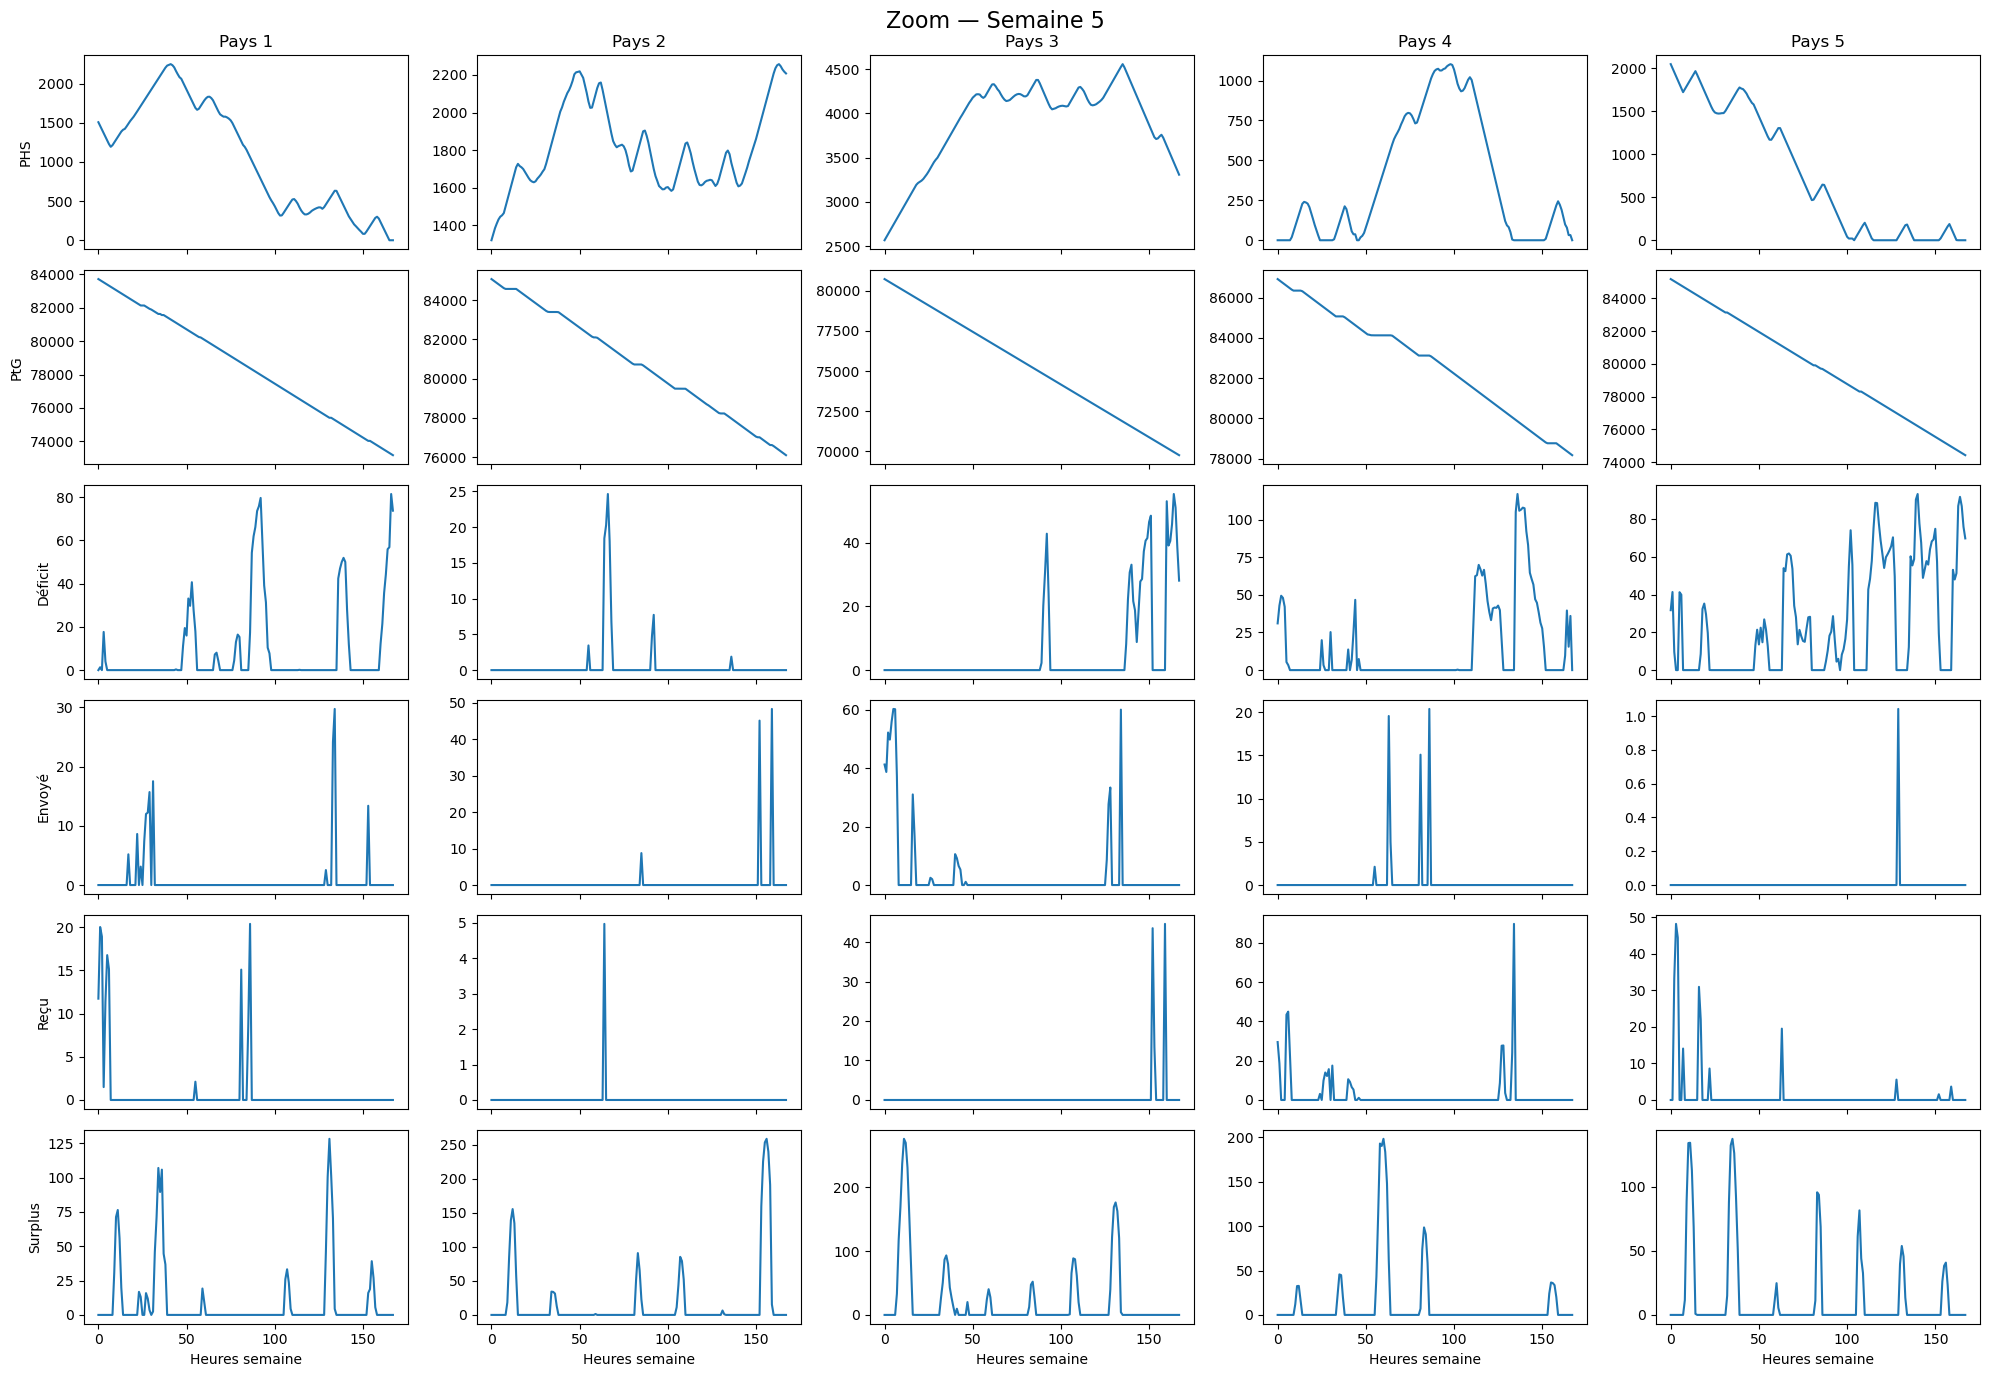

In [26]:
N = result['phs_level'].shape[1]

# --- Flux ---
q = result["Echanges"]  # (T, N, N)
sent = np.sum(q, axis=2)
received = np.sum(q, axis=1)

# =====================================================
# GRAPHE GLOBAL (8760 heures)
# =====================================================


fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][:, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][:, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][:, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[:, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[:, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")

    axes[5, i].plot(result['surplus'][:, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Temps")

plt.suptitle("Résultats sur 4000 heures", fontsize=16)
plt.tight_layout()
plt.show()


# =====================================================
# ZOOM SEMAINE
# =====================================================
semaine = 5
T0 = 168 * (semaine - 1)
T1 = T0 + 168

fig, axes = plt.subplots(6, N, figsize=(20, 14), sharex=True)

for i in range(N):

    axes[0, i].plot(result['phs_level'][T0:T1, i])
    if i == 0: axes[0, i].set_ylabel("PHS")
    axes[0, i].set_title(f"Pays {i+1}")

    axes[1, i].plot(result['ptg_level'][T0:T1, i])
    if i == 0: axes[1, i].set_ylabel("PtG")

    axes[2, i].plot(result['deficit'][T0:T1, i])
    if i == 0: axes[2, i].set_ylabel("Déficit")

    axes[3, i].plot(sent[T0:T1, i])
    if i == 0: axes[3, i].set_ylabel("Envoyé")

    axes[4, i].plot(received[T0:T1, i])
    if i == 0: axes[4, i].set_ylabel("Reçu")
    
    axes[5, i].plot(result['surplus'][T0:T1, i])
    if i == 0: axes[5, i].set_ylabel("Surplus")
    axes[5, i].set_xlabel("Heures semaine")

plt.suptitle(f"Zoom — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

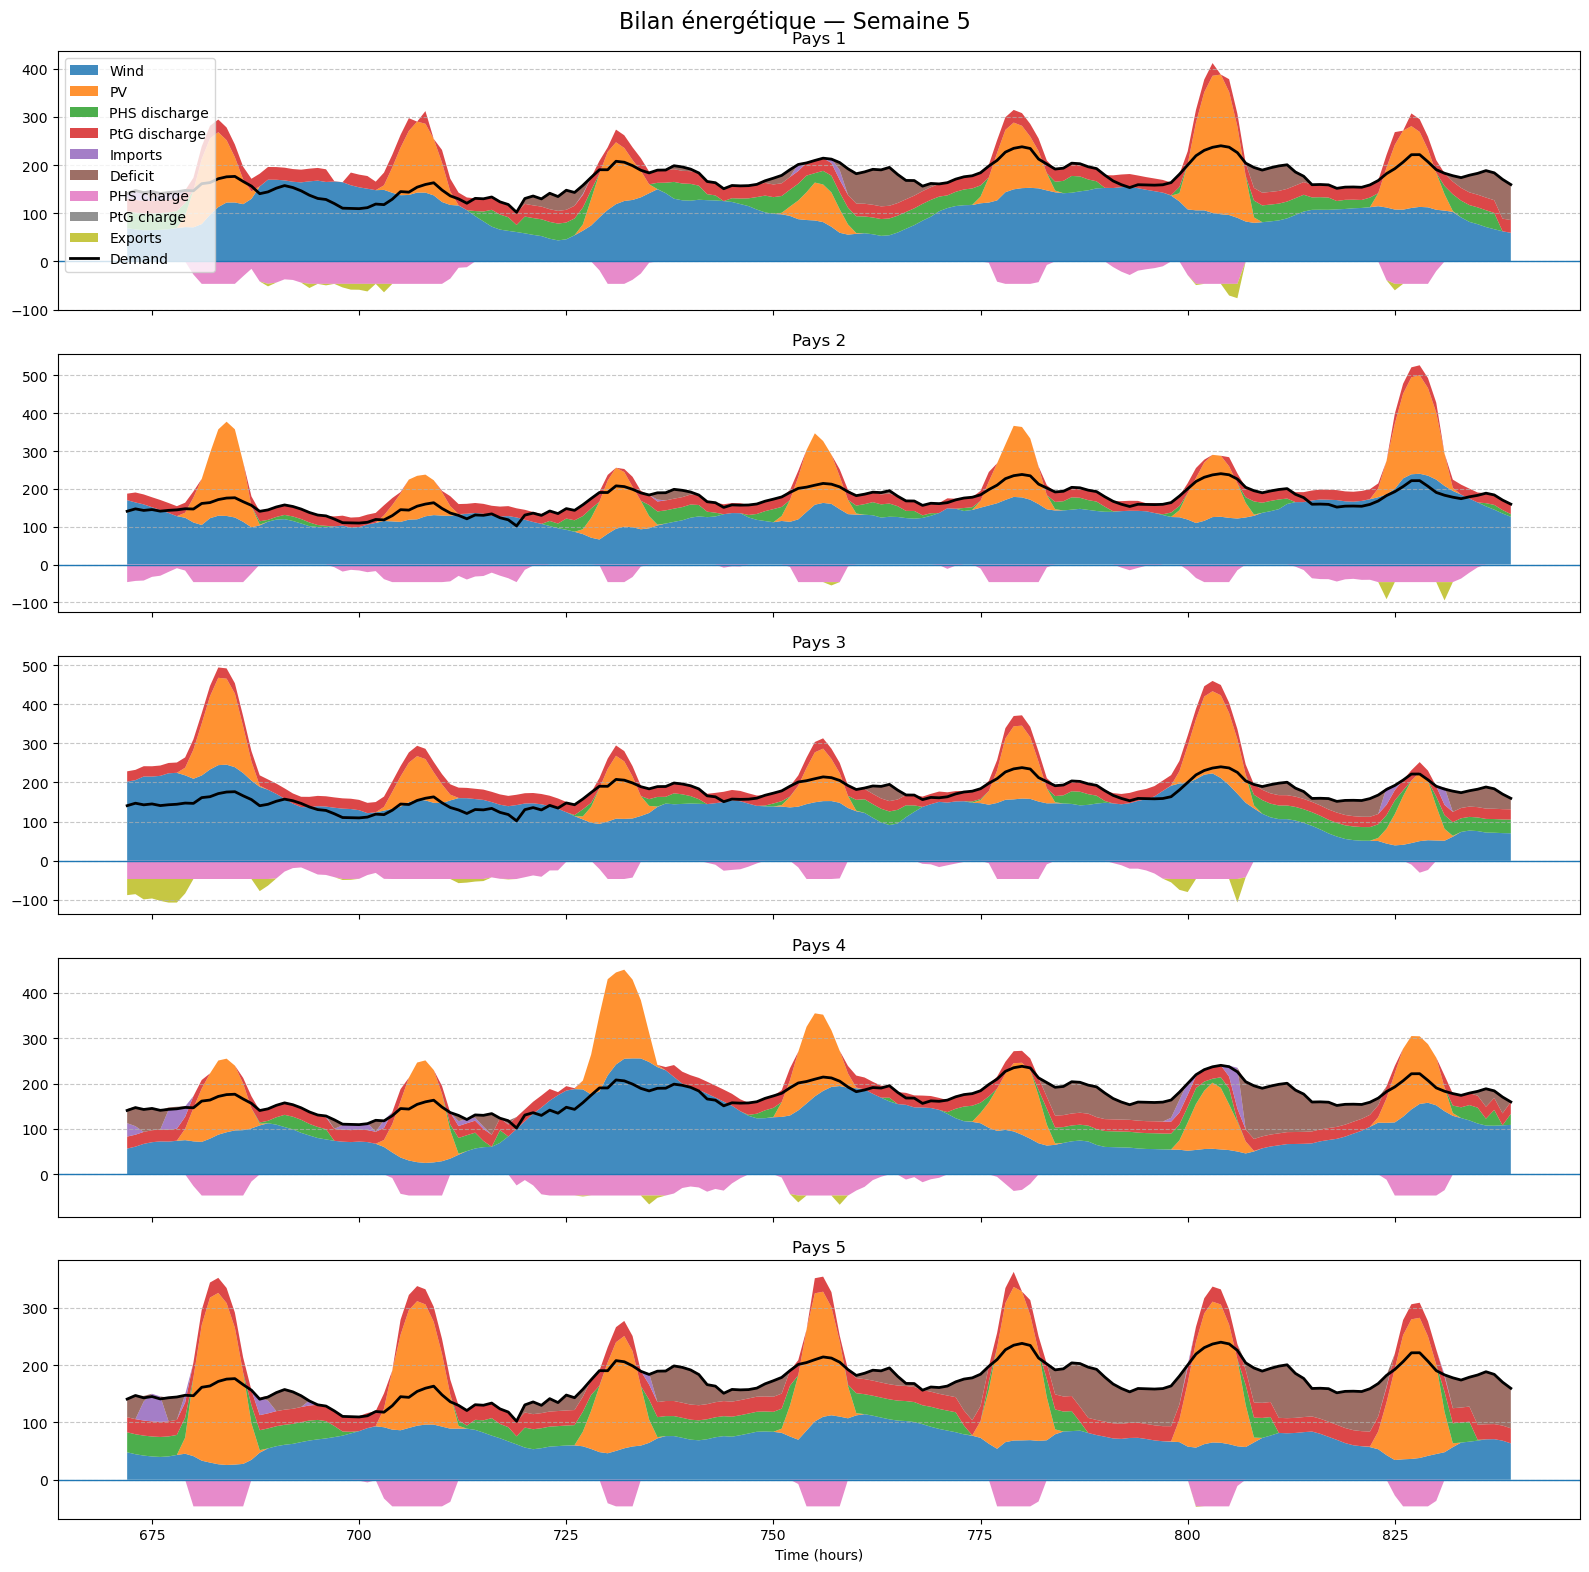

In [12]:
# ===============================
# Flux échanges
# ===============================

ptg_eff=0.4
phs_eff = 0.75
time_axis = np.arange(T0, T1)

q = result["Echanges"]

imports = np.sum(q, axis=1)
exports = np.sum(q, axis=2)

fig, axes = plt.subplots(N, 1, figsize=(16, 16), sharex=True)

for i in range(N):

    # --- Production ---
    wind_i = (wind_N*wind_cap_N)[T0:T1, i]
    solar_i = (solar_N*solar_cap_N)[T0:T1, i]

    # --- Déstockage ---
    phs_dis = phs_eff * result['phs_out'][T0:T1, i]
    ptg_dis = ptg_eff * result['ptg_out'][T0:T1, i]

    # --- Stockage (négatif) ---
    phs_ch = -result['phs_in'][T0:T1, i]
    ptg_ch = -result['ptg_in'][T0:T1, i]

    # --- Echanges ---
    import_i = imports[T0:T1, i]
    export_i = -exports[T0:T1, i]   # NEGATIF

    deficit_i = result['deficit'][T0:T1, i]
    demand_i = demand_N[T0:T1, i]

    # ===== STACK POSITIF =====
    stack_pos = [
        wind_i,
        solar_i,
        phs_dis,
        ptg_dis,
        import_i,
        deficit_i
    ]

    labels_pos = [
        'Wind',
        'PV',
        'PHS discharge',
        'PtG discharge',
        'Imports',
        'Deficit'
    ]

    axes[i].stackplot(time_axis, stack_pos, alpha=0.85)

    # ===== STACK NEGATIF =====
    stack_neg = [
        phs_ch,
        ptg_ch,
        export_i
    ]

    axes[i].stackplot(time_axis, stack_neg, alpha=0.85)

    # --- Demande ---
    axes[i].plot(time_axis,
                 demand_i,
                 color='black',
                 linewidth=2,
                 label='Demand')

    axes[i].axhline(0, linewidth=1)

    axes[i].set_title(f"Pays {i+1}")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    if i == 0:
        axes[i].legend(labels_pos + ['PHS charge','PtG charge','Exports','Demand'],
                       loc='upper left', fontsize=10)

axes[-1].set_xlabel("Time (hours)")
plt.suptitle(f"Bilan énergétique — Semaine {semaine}", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
def compute_static_pos(qmax_matrix):
    N = qmax_matrix.shape[0]
    G = nx.DiGraph()

    # Création structure graphique
    for i in range(N):
        G.add_node(i)
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G.add_edge(i, j)

    return nx.spring_layout(G, seed=42)


def show_graphs(prod_matrix, demand_matrix, qmax_matrix,
                q_array, r_pos_array, r_neg_array,
                pos, period=0):

    T, N = prod_matrix.shape

    # ===== 1️⃣ Graphe Capacités qmax =====
    G1 = nx.DiGraph()
    Q = prod_matrix[period] - demand_matrix[period]

    for i in range(N):
        G1.add_node(i, Q=Q[i])
    for i in range(N):
        for j in range(N):
            if i != j and qmax_matrix[i, j] > 0:
                G1.add_edge(i, j, qmax=qmax_matrix[i, j])

    node_colors1 = ["#6BC729" if Q[i] >= 0 else "#F77260" for i in G1.nodes()]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Taille des arêtes FIXE
    nx.draw(G1, pos, ax=axes[0], node_color=node_colors1,
            node_size=4500, width=2, edge_color="#7D7D7D",
            arrowsize=20)

    # Labels noeuds
    labels1 = {i: f"P{i+1}\nQ={Q[i]:.1f}" for i in G1.nodes()}
    nx.draw_networkx_labels(
        G1, pos,
        labels=labels1,
        font_size=13,
        font_weight="bold",
        ax=axes[0]
    )

    # Labels arêtes qmax
    edge_labels1 = {(i, j): f"{G1.edges[i, j]['qmax']:.1f}" for i, j in G1.edges()}
    nx.draw_networkx_edge_labels(
        G1, pos,
        edge_labels=edge_labels1,
        font_size=15,
        font_weight="bold",
        ax=axes[0]
    )

    axes[0].set_title(f"Capacités qmax - Période {period}")


    # ===== 2️⃣ Graphe flux réels =====
    G2 = nx.DiGraph()
    for i in range(N):
        r = r_pos_array[period, i] - r_neg_array[period, i]
        G2.add_node(i, r=r)
    for i in range(N):
        for j in range(N):
            v = q_array[period, i, j]
            if i != j and v > 1e-6:
                G2.add_edge(i, j, flux=v)

    node_colors2 = ['#6BC729' if G2.nodes[i]['r'] >= 0 else "#F77260" for i in G2.nodes()]
    nx.draw(G2, pos, ax=axes[1], node_color=node_colors2,
            node_size=4500, width=2,
            edge_color="#337FEA", arrowsize=20)

    labels2 = {i: f"P{i+1}\nr={G2.nodes[i]['r']:.2f}" for i in G2.nodes()}
    nx.draw_networkx_labels(
        G2, pos,
        labels=labels2,
        font_size=13,
        font_weight="bold",
        ax=axes[1]
    )

    # Labels arêtes flux
    edge_labels2 = {(i, j): f"{G2.edges[i, j]['flux']:.2f}" for i, j in G2.edges()}
    nx.draw_networkx_edge_labels(
        G2, pos,
        edge_labels=edge_labels2,
        font_size=15,
        font_weight="bold",
        ax=axes[1]
    )


    axes[1].set_title("Flux optimisés")

    plt.show()



# === Fonction interactive finale ===
def interactive_graphs(prod, dem, qmax, q, r_pos, r_neg):
    pos = compute_static_pos(qmax)
    T = prod.shape[0]

    interact(lambda period: show_graphs(prod, dem, qmax, q, r_pos, r_neg, pos, period),
             period=IntSlider(min=0, max=T-1, step=1, value=0, description="Temps"))

In [18]:
interactive_graphs(result['surplus avant echange'], result['deficit avant echange'], qmax, q, result['surplus'], result['deficit'])

interactive(children=(IntSlider(value=0, description='Temps', max=8759), Output()), _dom_classes=('widget-inte…